# Guided Numeric Exploration — US COVID, Pneumonia & Flu Deaths
_CDC-style weekly national and state death counts — parsing, shares, and seasonality_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [razanihababdellatif/us-covid-19-pneumonia-and-flu-deaths-data](https://www.kaggle.com/datasets/razanihababdellatif/us-covid-19-pneumonia-and-flu-deaths-data)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup, Parse & Suppression](#Setup)** <br>
**3. [National Weekly Series](#National)** <br>
**4. [Cause Shares](#Shares)** <br>
**5. [State Heatmap & Ranking](#States)** <br>
**6. [Flu vs COVID Scatter](#FluCovid)** <br>
**7. [Month × Year Seasonality](#Seasonality)** <br>
**8. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
CDC-style provisional death counts for COVID-19, pneumonia, and influenza across US jurisdictions. Rows are grouped as **By Week**, **By Month**, **By Year**, and **By Total**. Analyses prefer **By Week**.

Death-count columns arrive as **strings with commas** (and blanks for suppressed small counts) — they must be parsed to numeric before any math.


# **2. Setup, Parse & Suppression:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "covid_pneumonia_flu_deaths_us.csv"
KAGGLE_SLUG = "razanihababdellatif/us-covid-19-pneumonia-and-flu-deaths-data"
EXPECTED_COLS = [
    "Data as of", "Start Date", "End Date", "Group", "Year", "Month", "MMWR Week",
    "Week Ending Date", "State", "COVID-19 Deaths", "Total Deaths",
    "Percent of Expected Deaths", "Pneumonia Deaths", "Pneumonia and COVID-19 Deaths",
    "Influenza Deaths", "Pneumonia, Influenza, or COVID-19 Deaths", "Footnote",
]
DEATH_COLS = [
    "COVID-19 Deaths", "Total Deaths", "Pneumonia Deaths",
    "Pneumonia and COVID-19 Deaths", "Influenza Deaths",
    "Pneumonia, Influenza, or COVID-19 Deaths",
]


def resolve_csv_path(basename: str = CSV_BASENAME) -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(basename):
            return p
    local_data = Path("data") / basename
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / basename
    if not p.exists():
        hits = list(root.rglob(basename))
        assert hits, f"expected {basename} under {root}"
        p = hits[0]
    return p


def parse_count(series: pd.Series) -> pd.Series:
    """Parse comma-formatted count strings; blanks → NaN (suppression)."""
    s = series.astype(str).str.strip()
    s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan, "NaN": np.nan})
    s = s.str.replace(",", "", regex=False)
    return pd.to_numeric(s, errors="coerce")


csv_path = resolve_csv_path()
print("CSV:", csv_path)
raw = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(raw.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(raw) == 23220, f"expected 23220 rows, got {len(raw)}"
assert raw.shape[1] == 17, f"expected 17 cols, got {raw.shape[1]}"
assert set(raw["Group"].unique()) <= {"By Week", "By Month", "By Year", "By Total"}

df = raw.copy()
for c in DEATH_COLS:
    assert df[c].dtype == object or str(df[c].dtype) in ("string", "str", "object"), f"{c} should be string-like before parse"
    df[c] = parse_count(df[c])

df["Week Ending Date"] = pd.to_datetime(df["Week Ending Date"], errors="coerce")
df["Start Date"] = pd.to_datetime(df["Start Date"], errors="coerce")
df["suppressed_flag"] = df["Footnote"].notna().astype(int)

print("Group counts:")
display(df["Group"].value_counts())
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Parsed death-col null rates (suppression / missing):")
display(df[DEATH_COLS].isna().mean().round(3).to_frame("null_rate"))
display(df.sample(5, random_state=7))


CSV: /kaggle/input/datasets/razanihababdellatif/us-covid-19-pneumonia-and-flu-deaths-data/covid_pneumonia_flu_deaths_us.csv
Group counts:


Group
By Week     18522
By Month     4266
By Year       378
By Total       54
Name: count, dtype: int64

Dataframe Dimension: 23220 Rows, 18 Columns
Parsed death-col null rates (suppression / missing):


,null_rate
COVID-19 Deaths,0.274
Total Deaths,0.000
Pneumonia Deaths,0.074
Pneumonia and COVID-19 Deaths,0.385
Influenza Deaths,0.413
"Pneumonia, Influenza, or COVID-19 Deaths",0.051


,Data as of,Start Date,End Date,Group,Year,Month,MMWR Week,Week Ending Date,State,COVID-19 Deaths,Total Deaths,Percent of Expected Deaths,Pneumonia Deaths,Pneumonia and COVID-19 Deaths,Influenza Deaths,"Pneumonia, Influenza, or COVID-19 Deaths",Footnote,suppressed_flag
18016,07/30/2026,2023-06-11,06/17/2023,By Week,2023,NaN,24.0,2023-06-17,Wyoming,0.0,97.0,124.0,NaN,0.0,0.0,NaN,One or more data cells have counts between 1-9...,1
7561,07/30/2026,2020-04-12,04/18/2020,By Week,2020,NaN,16.0,2020-04-18,Massachusetts,1115.0,2494.0,217.0,505.0,370.0,NaN,1254.0,One or more data cells have counts between 1-9...,1
9898,07/30/2026,2025-08-17,08/23/2025,By Week,2025,NaN,34.0,2025-08-23,Nebraska,NaN,321.0,103.0,12.0,0.0,0.0,13.0,One or more data cells have counts between 1-9...,1
14716,07/30/2026,2025-12-07,12/13/2025,By Week,2025,NaN,50.0,2025-12-13,South Carolina,NaN,1187.0,116.0,59.0,0.0,NaN,66.0,One or more data cells have counts between 1-9...,1
5992,07/30/2026,2023-01-29,02/04/2023,By Week,2023,NaN,5.0,2023-02-04,Kansas,13.0,581.0,104.0,22.0,NaN,NaN,33.0,One or more data cells have counts between 1-9...,1


**Code Explanation and Reasoning:** <br>
Schema and 23,220×17 shape are asserted. Comma-formatted death strings are coerced to numeric; blanks become NaN (NCHS suppression for small counts). `suppressed_flag` tracks footnote presence. Prefer **By Week** going forward.


In [3]:
week = df[df["Group"] == "By Week"].copy()
assert len(week) == 18522, f"expected 18522 weekly rows, got {len(week)}"
print("Weekly rows:", len(week), "| States/jurisdictions:", week["State"].nunique())
print("Week ending range:", week["Week Ending Date"].min(), "→", week["Week Ending Date"].max())
unique_count = [[c, week[c].nunique(dropna=False), int(week[c].isnull().sum())] for c in week.columns]
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Null", ascending=False))


Weekly rows: 18522 | States/jurisdictions: 54
Week ending range: 2020-01-04 00:00:00 → 2026-07-25 00:00:00


,Column,Unique,Null
5,Month,1,18522
13,Pneumonia and COVID-19 Deaths,748,7886
14,Influenza Deaths,205,7496
9,COVID-19 Deaths,1047,5833
16,Footnote,2,5192
12,Pneumonia Deaths,1080,1714
15,"Pneumonia, Influenza, or COVID-19 Deaths",1301,1177
10,Total Deaths,3893,1
1,Start Date,343,0
0,Data as of,1,0


**Interpretation** <br>
Weekly rows dominate. Nulls in influenza / pneumonia+COVID cells are largely suppression, not calendar gaps. United States rows are the national series; state rows enable heatmaps.


# **3. National Weekly Series:** <a id="National"></a>


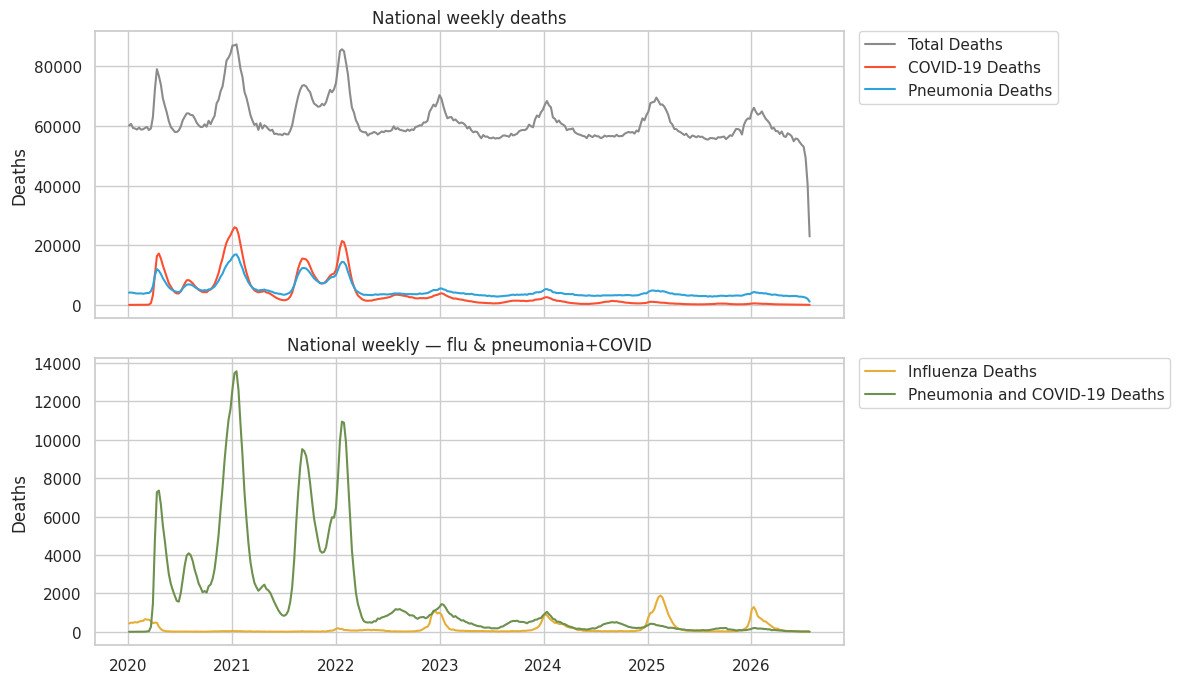

In [4]:
nat = week[week["State"] == "United States"].sort_values("Week Ending Date")
assert len(nat) > 100, "expected a long national weekly series"
assert nat["Week Ending Date"].notna().all()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(nat["Week Ending Date"], nat["Total Deaths"], color="#8b8b8b", label="Total Deaths")
axes[0].plot(nat["Week Ending Date"], nat["COVID-19 Deaths"], color="#fc4f30", label="COVID-19 Deaths")
axes[0].plot(nat["Week Ending Date"], nat["Pneumonia Deaths"], color="#30a2da", label="Pneumonia Deaths")
axes[0].set_ylabel("Deaths")
axes[0].set_title("National weekly deaths")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
axes[1].plot(nat["Week Ending Date"], nat["Influenza Deaths"], color="#e5ae38", label="Influenza Deaths")
axes[1].plot(nat["Week Ending Date"], nat["Pneumonia and COVID-19 Deaths"], color="#6d904f",
             label="Pneumonia and COVID-19 Deaths")
axes[1].set_ylabel("Deaths")
axes[1].set_title("National weekly — flu & pneumonia+COVID")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()


**Interpretation** <br>
National weekly lines show COVID waves against a relatively stable total-death baseline, with flu spikes in winter seasons. Pneumonia+COVID tracks COVID peaks when co-listed deaths surge.


# **4. Cause Shares:** <a id="Shares"></a>


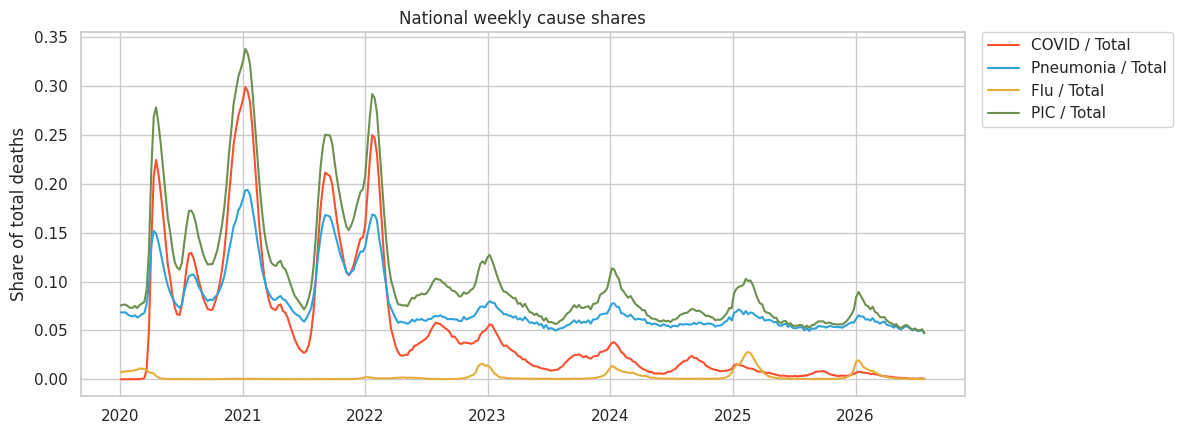

,covid_share,pneumonia_share,flu_share,pic_share
count,343.0000,343.0000,343.0000,343.0000
mean,0.0526,0.0765,0.0028,0.1063
std,0.0672,0.0322,0.0048,0.0628
min,0.0000,0.0470,0.0001,0.0474
25%,0.0078,0.0567,0.0003,0.0650
50%,0.0241,0.0631,0.0007,0.0830
75%,0.0704,0.0804,0.0025,0.1181
max,0.2989,0.1936,0.0280,0.3379


In [5]:
# Shares of total deaths (national weekly)
nat = nat.copy()
for c, name in [
    ("COVID-19 Deaths", "covid_share"),
    ("Pneumonia Deaths", "pneumonia_share"),
    ("Influenza Deaths", "flu_share"),
    ("Pneumonia, Influenza, or COVID-19 Deaths", "pic_share"),
]:
    nat[name] = nat[c] / nat["Total Deaths"]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(nat["Week Ending Date"], nat["covid_share"], label="COVID / Total", color="#fc4f30")
ax.plot(nat["Week Ending Date"], nat["pneumonia_share"], label="Pneumonia / Total", color="#30a2da")
ax.plot(nat["Week Ending Date"], nat["flu_share"], label="Flu / Total", color="#e5ae38")
ax.plot(nat["Week Ending Date"], nat["pic_share"], label="PIC / Total", color="#6d904f")
ax.set_ylabel("Share of total deaths")
ax.set_title("National weekly cause shares")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()
display(nat[["covid_share", "pneumonia_share", "flu_share", "pic_share"]].describe().round(4))


**Interpretation** <br>
Shares normalize for population/total mortality drift. COVID share dominates pandemic peaks; flu share is smaller but seasonally sharp. PIC (pneumonia, influenza, or COVID) is the combined respiratory envelope.


# **5. State Heatmap & Ranking:** <a id="States"></a>


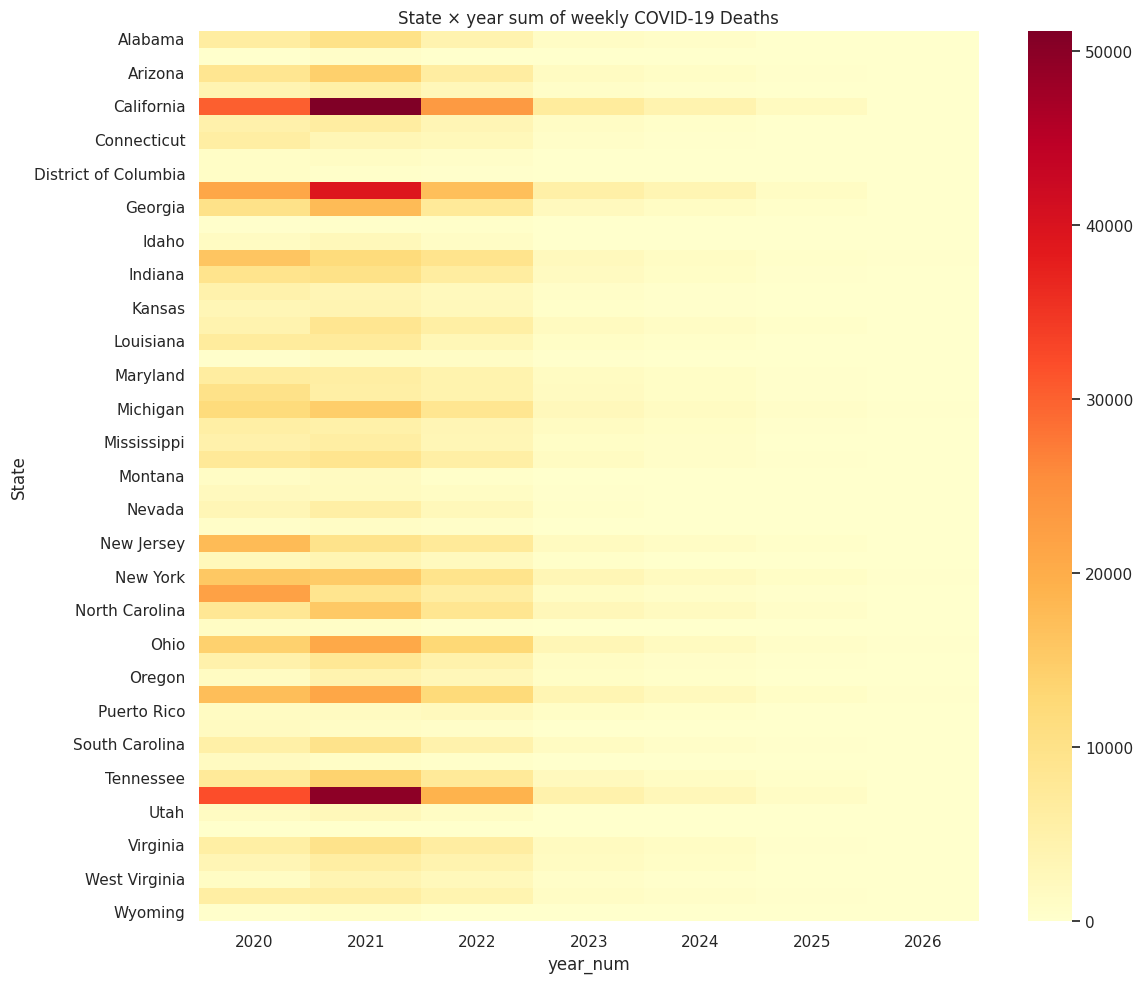

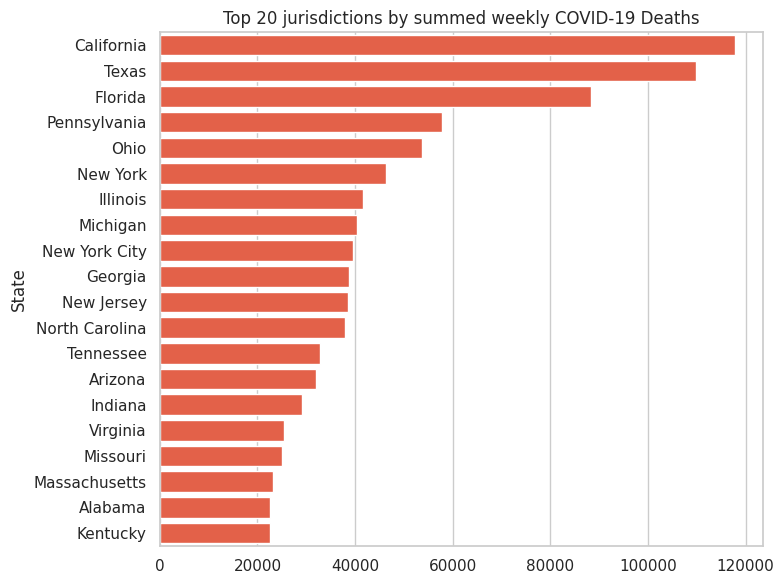

,covid_deaths_sum
State,
California,117767.0
Texas,109835.0
Florida,88421.0
Pennsylvania,57813.0
Ohio,53801.0
New York,46265.0
Illinois,41580.0
Michigan,40287.0
New York City,39574.0


In [6]:
# State weekly (exclude United States)
st = week[week["State"] != "United States"].copy()
# Annual COVID death sums by state (skip fully-null years)
st["year_num"] = st["Week Ending Date"].dt.year
state_year = st.pivot_table(index="State", columns="year_num", values="COVID-19 Deaths", aggfunc="sum")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(state_year, cmap="YlOrRd", ax=ax)
ax.set_title("State × year sum of weekly COVID-19 Deaths")
plt.tight_layout()
plt.show()

# Ranking: total COVID deaths across weekly rows
rank = (
    st.groupby("State")["COVID-19 Deaths"].sum(min_count=1)
    .sort_values(ascending=False)
    .head(20)
)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=rank.values, y=rank.index, ax=ax, color="#fc4f30")
ax.set_title("Top 20 jurisdictions by summed weekly COVID-19 Deaths")
plt.tight_layout()
plt.show()
display(rank.to_frame("covid_deaths_sum").head(10))


**Interpretation** <br>
State×year heatmaps show timing and intensity differences; rankings reflect population size as much as severity. Suppressed weeks mean sums are lower bounds for small jurisdictions.


# **6. Flu vs COVID Scatter:** <a id="FluCovid"></a>


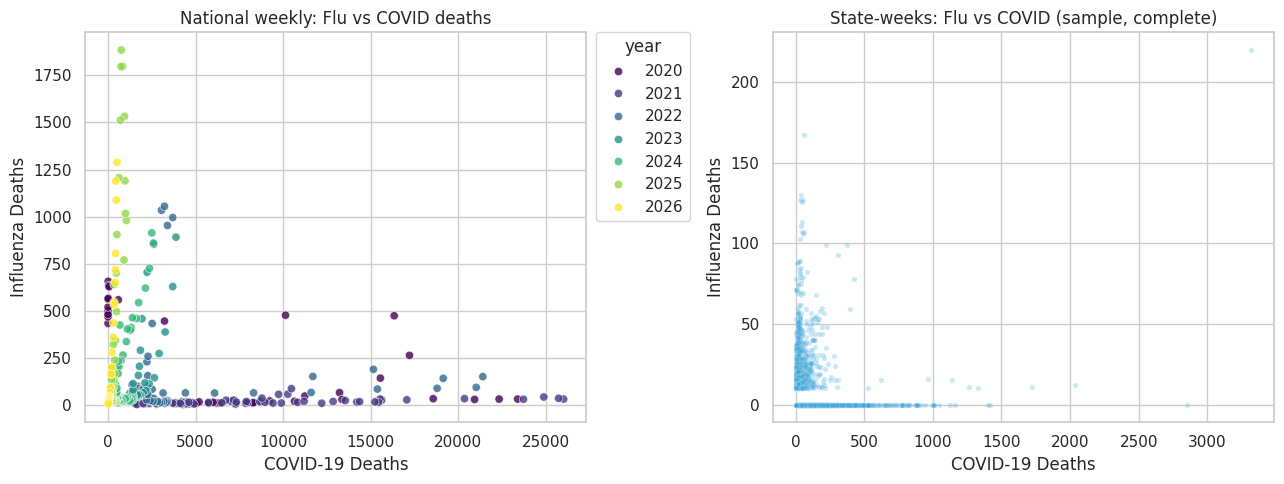

National weekly Spearman(COVID, Flu)=-0.301, p=1.23e-08


In [7]:
# National weekly flu vs COVID
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(
    data=nat, x="COVID-19 Deaths", y="Influenza Deaths",
    hue=nat["Week Ending Date"].dt.year, palette="viridis", alpha=0.8, ax=axes[0],
)
axes[0].set_title("National weekly: Flu vs COVID deaths")
axes[0].legend(title="year", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

# State-week sample: complete cases only
sample = st.dropna(subset=["COVID-19 Deaths", "Influenza Deaths"]).sample(
    min(4000, st.dropna(subset=["COVID-19 Deaths", "Influenza Deaths"]).shape[0]),
    random_state=7,
)
sns.scatterplot(
    data=sample, x="COVID-19 Deaths", y="Influenza Deaths",
    alpha=0.25, s=14, ax=axes[1], color="#30a2da",
)
axes[1].set_title("State-weeks: Flu vs COVID (sample, complete)")
plt.tight_layout()
plt.show()

r, p = stats.spearmanr(nat["COVID-19 Deaths"], nat["Influenza Deaths"], nan_policy="omit")
print(f"National weekly Spearman(COVID, Flu)={r:.3f}, p={p:.3g}")


**Interpretation** <br>
Flu vs COVID is not a simple positive couple — pandemic years often show COVID spikes with depressed flu circulation. Year hue on the national scatter makes that regime shift visible.


# **7. Month × Year Seasonality:** <a id="Seasonality"></a>


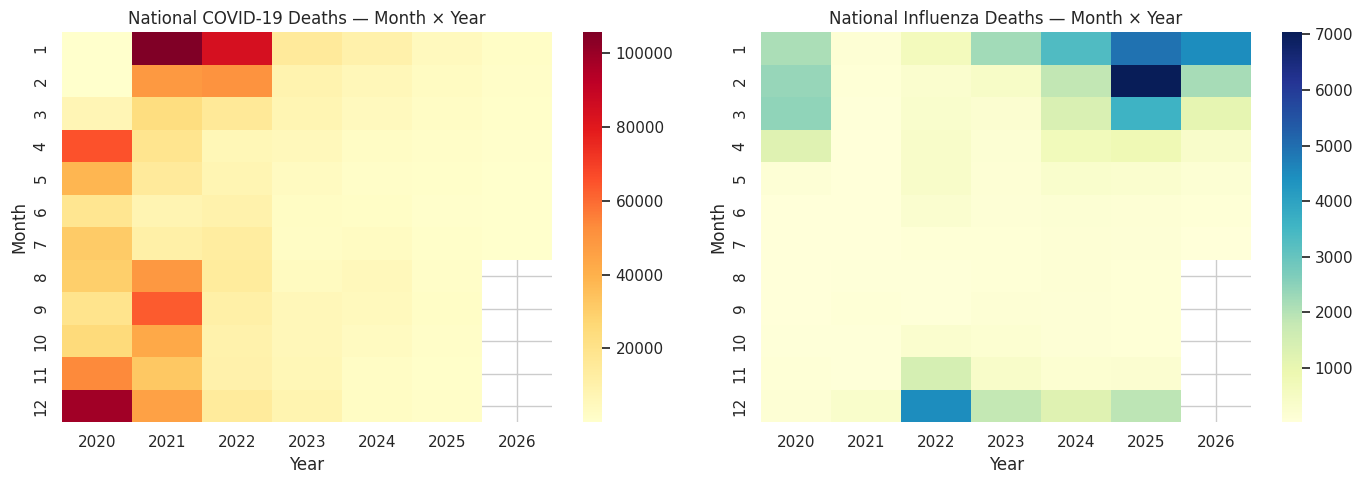

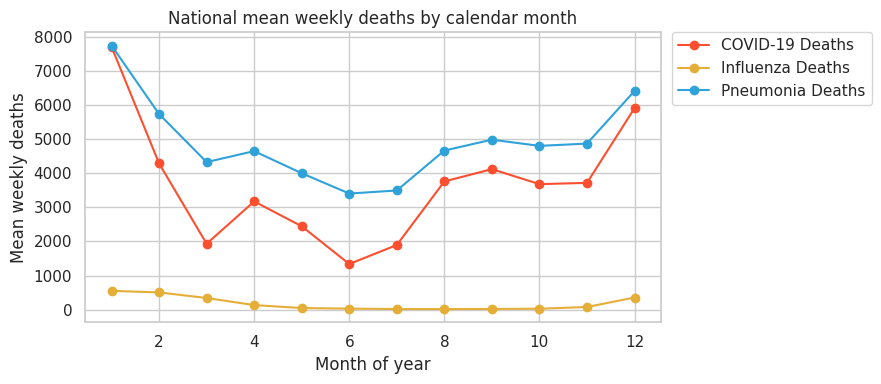

In [8]:
# Prefer By Month group for clean month×year totals (national)
month = df[(df["Group"] == "By Month") & (df["State"] == "United States")].copy()
assert len(month) > 20
# Year may be string; Month is float
month["Year"] = month["Year"].astype(str)
month["Month"] = month["Month"].astype(int)
piv = month.pivot_table(index="Month", columns="Year", values="COVID-19 Deaths", aggfunc="sum")
piv_flu = month.pivot_table(index="Month", columns="Year", values="Influenza Deaths", aggfunc="sum")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(piv, cmap="YlOrRd", ax=axes[0])
axes[0].set_title("National COVID-19 Deaths — Month × Year")
sns.heatmap(piv_flu, cmap="YlGnBu", ax=axes[1])
axes[1].set_title("National Influenza Deaths — Month × Year")
plt.tight_layout()
plt.show()

# Weekly seasonality proxy: month-of-year mean (national)
nat["moy"] = nat["Week Ending Date"].dt.month
seas = nat.groupby("moy")[["COVID-19 Deaths", "Influenza Deaths", "Pneumonia Deaths"]].mean()
fig, ax = plt.subplots(figsize=(9, 4))
seas.plot(ax=ax, marker="o", color=["#fc4f30", "#e5ae38", "#30a2da"])
ax.set_xlabel("Month of year")
ax.set_ylabel("Mean weekly deaths")
ax.set_title("National mean weekly deaths by calendar month")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()


**Interpretation** <br>
Month×year heatmaps separate winter respiratory seasonality (flu) from COVID wave timing (which is less strictly seasonal). Calendar-month means average across years — useful as a teaching seasonality view, not a forecast.


# **8. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
CDC-style US COVID / pneumonia / influenza death counts with week/month/year/total groupings and NCHS suppression footnotes.

**Working takeaways:** <br>
- Death counts are strings with commas — parsing is mandatory; blanks are suppression, not zeros.
- Prefer **By Week**; national United States rows give the cleanest time series.
- Cause shares show COVID wave dominance; flu remains a sharp winter signal.
- State rankings mix population and severity; suppressed cells bias small-jurisdiction sums downward.
- Flu vs COVID often anti-aligns across pandemic regimes; month×year heatmaps separate seasonal flu from COVID waves.

**Open follow-ups:** <br>
- Age-standardized rates if a population join becomes available.
- Excess deaths via Percent of Expected Deaths during peak COVID weeks.
- State heterogeneity in pneumonia+COVID co-listing rates.
